In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

df = pd.read_csv("cleaned_viratkohli.csv")

# Convert date to datetime
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Create year column
df["year"] = df["date"].dt.year

# Create folder for charts
os.makedirs("charts", exist_ok=True)

sns.set_theme(style="whitegrid")

print("Dataset loaded successfully!")
print(df.columns.tolist())

display(df.head())

Dataset loaded successfully!
['runs', 'opponent', 'ground', 'date', 'match', 'Match_No', 'total', 'year']


,runs,opponent,ground,date,match,Match_No,total,year
0,12,SriLanka,Dambulla,2008-08-18,ODI,1,12,2008
1,37,SriLanka,Dambulla,2008-08-20,ODI,2,49,2008
2,25,SriLanka,Colombo(RPS),2008-08-24,ODI,3,74,2008
3,54,SriLanka,Colombo(RPS),2008-08-27,ODI,4,128,2008
4,31,SriLanka,Colombo(RPS),2008-08-29,ODI,5,159,2008


In [2]:
pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


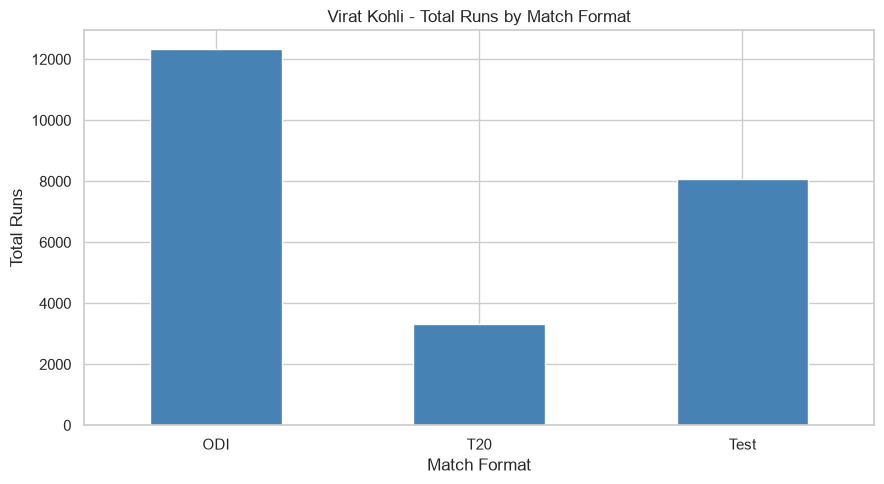

In [3]:

format_runs = df.groupby("match")["runs"].sum()

plt.figure(figsize=(9, 5))

format_runs.plot(kind="bar", color="steelblue")

plt.title("Virat Kohli - Total Runs by Match Format")
plt.xlabel("Match Format")
plt.ylabel("Total Runs")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig("charts/01_runs_by_format.png", dpi=300)
plt.show()

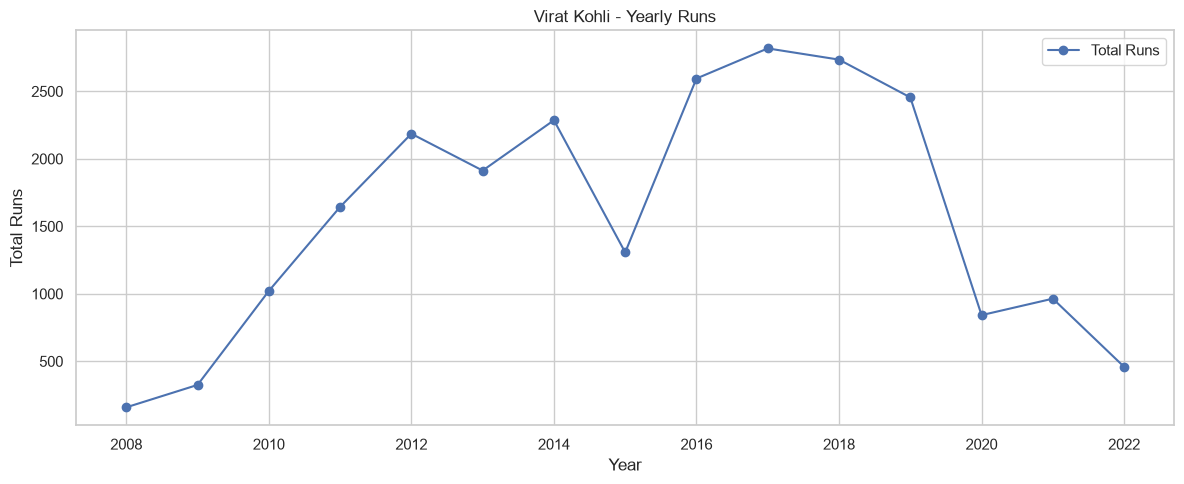

In [4]:

yearly_runs = df.groupby("year")["runs"].sum().dropna()

plt.figure(figsize=(12, 5))

plt.plot(
    yearly_runs.index,
    yearly_runs.values,
    marker="o",
    label="Total Runs"
)

plt.title("Virat Kohli - Yearly Runs")
plt.xlabel("Year")
plt.ylabel("Total Runs")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("charts/02_yearly_runs.png", dpi=300)
plt.show()

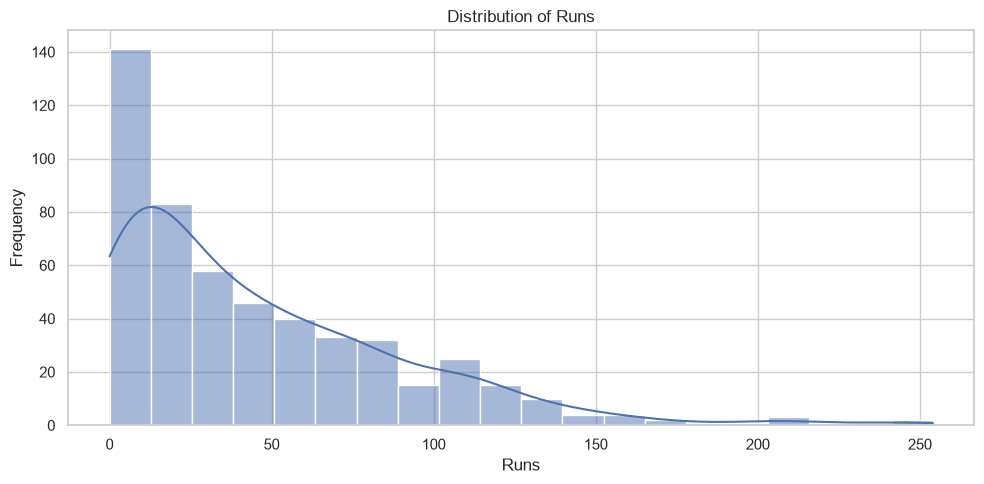

In [5]:

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="runs",
    bins=20,
    kde=True
)

plt.title("Distribution of Runs")
plt.xlabel("Runs")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("charts/03_runs_distribution.png", dpi=300)
plt.show()

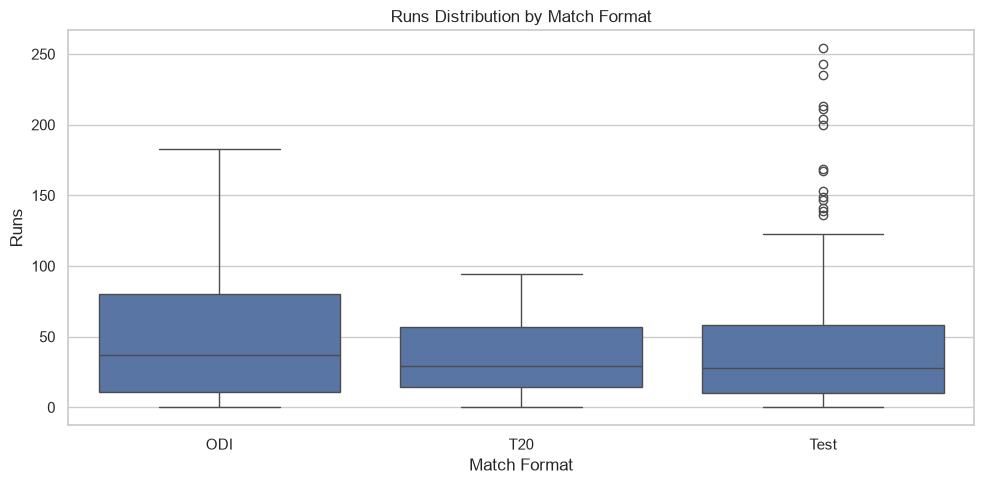

In [6]:

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="match",
    y="runs"
)

plt.title("Runs Distribution by Match Format")
plt.xlabel("Match Format")
plt.ylabel("Runs")

plt.tight_layout()
plt.savefig("charts/04_runs_boxplot.png", dpi=300)
plt.show()

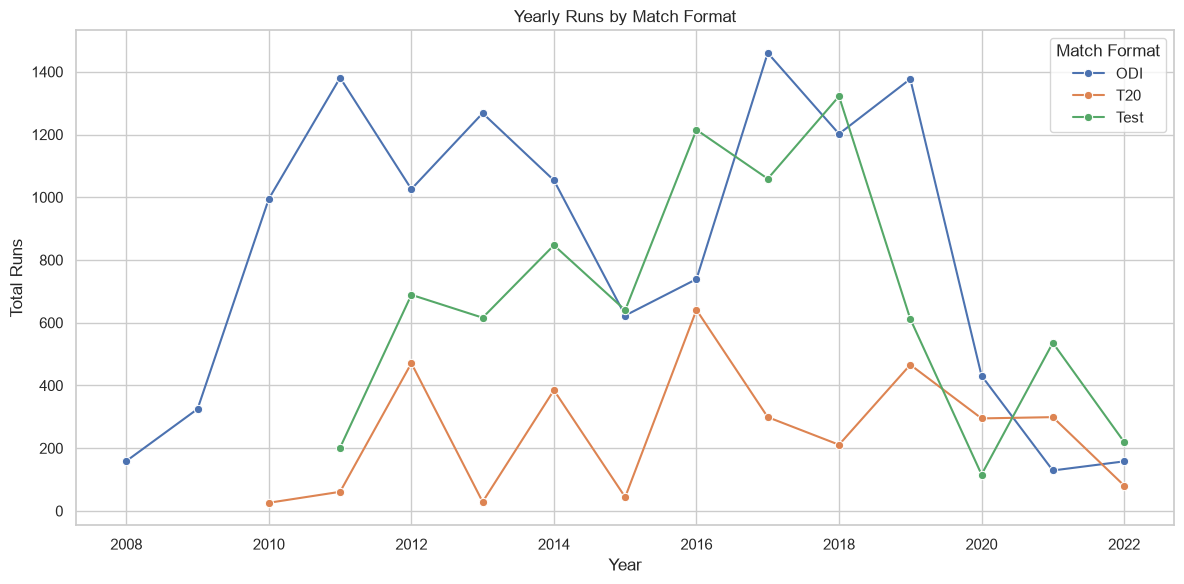

In [7]:

year_format = df.groupby(
    ["year", "match"]
)["runs"].sum().reset_index()

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=year_format,
    x="year",
    y="runs",
    hue="match",
    marker="o"
)

plt.title("Yearly Runs by Match Format")
plt.xlabel("Year")
plt.ylabel("Total Runs")
plt.legend(title="Match Format")

plt.tight_layout()
plt.savefig("charts/05_yearly_runs_by_format.png", dpi=300)
plt.show()